# TP1 : Clustering K-means + ACP — jeu de donnees *Wine*

**Donnees reelles.** Le dataset *Wine* (scikit-learn) decrit **178 vins** par
**13 mesures chimiques** (alcool, acidite, intensite de couleur, proline...).
Ces vins proviennent de **3 cepages**, mais on va faire **comme si on ne le
savait pas** : l'objectif est de **retrouver ces groupes** par clustering, puis
de **valider** le resultat contre les vrais cepages.

C'est un probleme d'**apprentissage non supervise**.

## Procede du TP
1. **Fonctionnement** : comprendre K-means + explorer les donnees
2. **Modelisation** : standardiser + choisir le nombre de clusters `k`
3. **Evaluation** : inertie, silhouette + validation vs cepage reel
4. **Visualisation** : projeter les clusters en 2D avec l'**ACP**
5. **Integration** : ranger le cluster de chaque vin dans la table
6. **Qualification** : decrire le profil chimique de chaque cluster

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED, GREEN, ORANGE = "#C0504D", "#3FA45B", "#F79646"
PALETTE = [ACCENT, NAVY, ORANGE, GREEN, RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees reelles

`load_wine` est inclus dans scikit-learn (aucun telechargement). On separe les
13 variables (`X`) du vrai cepage (`cepage`), que l'on garde **de cote** pour la
validation finale.

In [2]:
from sklearn.datasets import load_wine

ds = load_wine(as_frame=True)
X = ds.data
cepage = ds.target          # 0, 1, 2 : on ne s'en sert PAS pour clusteriser
print("dimensions :", X.shape)
X.head()

dimensions : (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 1. Fonctionnement de K-means

K-means regroupe les points en `k` clusters compacts, en repetant :
1. **Assigner** : chaque point rejoint le **centre le plus proche** ;
2. **Mettre a jour** : chaque centre devient la **moyenne** de ses points.

Il **minimise l'inertie** (somme des distances au carre des points a leur centre).

In [3]:
X.describe().round(2).T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
alcohol,13.00,0.81,11.03,14.83
malic_acid,2.34,1.12,0.74,5.80
ash,2.37,0.27,1.36,3.23
alcalinity_of_ash,19.49,3.34,10.60,30.00
magnesium,99.74,14.28,70.00,162.00
total_phenols,2.30,0.63,0.98,3.88
flavanoids,2.03,1.00,0.34,5.08
nonflavanoid_phenols,0.36,0.12,0.13,0.66
proanthocyanins,1.59,0.57,0.41,3.58
color_intensity,5.06,2.32,1.28,13.00


## 2. Modelisation

### 2.a Standardisation (indispensable)

Les variables ont des echelles tres differentes (`proline` ~ centaines,
`flavanoids` ~ unites). Comme K-means se base sur des **distances**, on met tout
a la **meme echelle** (moyenne 0, ecart-type 1).

In [4]:
from sklearn.preprocessing import StandardScaler

X_std = StandardScaler().fit_transform(X)
pd.DataFrame(X_std, columns=X.columns).describe().round(2).loc[['mean', 'std']].T.head()

,mean,std
alcohol,0.0,1.0
malic_acid,0.0,1.0
ash,-0.0,1.0
alcalinity_of_ash,-0.0,1.0
magnesium,-0.0,1.0


### 2.b Choisir `k` : methode du coude + silhouette

On teste plusieurs `k` et on combine deux criteres : le **coude** de l'inertie
et le **score de silhouette** (que l'on cherche a maximiser).

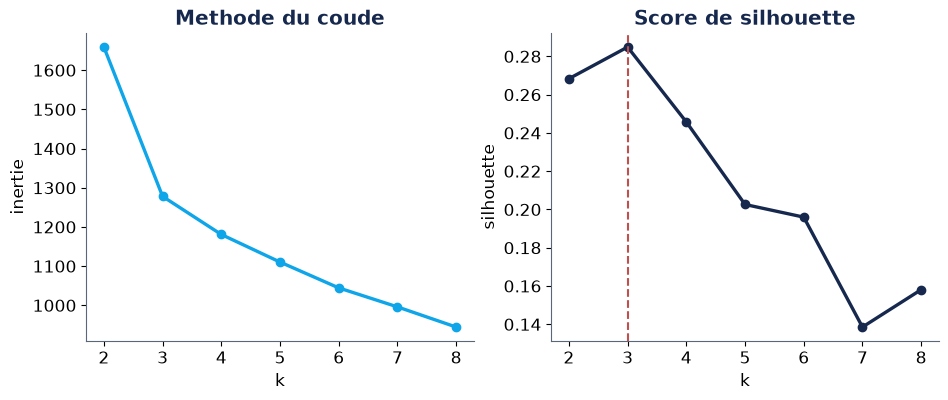

k retenu : 3


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 9)
inerties, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_std)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_std, km.labels_))

k_best = list(ks)[int(np.argmax(silhouettes))]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(ks), inerties, "-o", color=ACCENT, lw=2.4)
ax1.set(title="Methode du coude", xlabel="k", ylabel="inertie")
ax2.plot(list(ks), silhouettes, "-o", color=NAVY, lw=2.4)
ax2.axvline(k_best, color=RED, ls="--")
ax2.set(title="Score de silhouette", xlabel="k", ylabel="silhouette")
plt.show()
print("k retenu :", k_best)

> Le coude et la silhouette pointent vers **k = 3** : coherent avec les 3 cepages.

## 3. Evaluation + validation

On entraine le modele final, puis — **avantage de ce dataset** — on **compare les
clusters aux vrais cepages** avec l'*Adjusted Rand Index* (1 = accord parfait) et
un tableau croise.

In [6]:
from sklearn.metrics import adjusted_rand_score

km = KMeans(n_clusters=k_best, n_init=10, random_state=0).fit(X_std)
labels = km.labels_
print(f"Inertie    : {km.inertia_:.1f}")
print(f"Silhouette : {silhouette_score(X_std, labels):.3f}")
print(f"Adjusted Rand Index (clusters vs cepages) : {adjusted_rand_score(cepage, labels):.3f}")
pd.crosstab(labels, cepage, rownames=['cluster'], colnames=['cepage reel'])

Inertie    : 1277.9
Silhouette : 0.285
Adjusted Rand Index (clusters vs cepages) : 0.897


cepage reel,0,1,2
cluster,,,
0,0,65,0
1,0,3,48
2,59,3,0


> Un ARI proche de 0.9 montre que le clustering a **bien retrouve** la structure.

## 4. Visualisation avec l'ACP

13 dimensions ne se tracent pas. L'**ACP** projette les vins sur les 2 axes qui
**conservent le plus de variance**, pour visualiser les clusters en 2D.

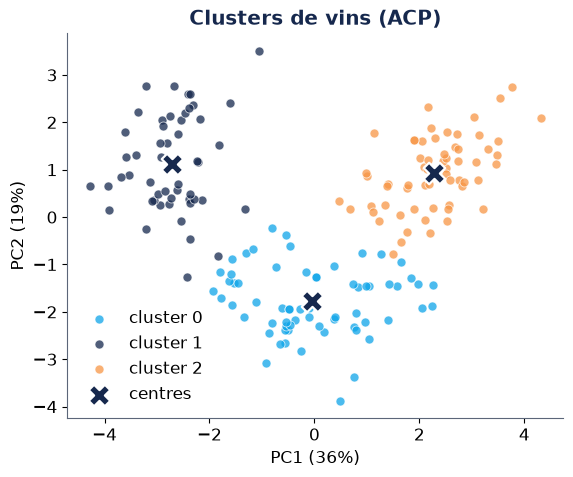

Variance expliquee par les 2 axes : 55%


In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(X_std)
centres = pca.transform(km.cluster_centers_)
var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(6.4, 5))
for c in sorted(np.unique(labels)):
    m = labels == c
    ax.scatter(coords[m, 0], coords[m, 1], s=42, alpha=0.75, color=PALETTE[c],
               edgecolor="white", linewidth=0.6, label=f"cluster {c}")
ax.scatter(centres[:, 0], centres[:, 1], marker="X", s=240, color=NAVY,
           edgecolor="white", linewidth=1.6, zorder=5, label="centres")
ax.set(title="Clusters de vins (ACP)", xlabel=f"PC1 ({var[0]:.0%})", ylabel=f"PC2 ({var[1]:.0%})")
ax.legend(frameon=False)
plt.show()
print(f"Variance expliquee par les 2 axes : {var.sum():.0%}")

## 5. Integration : ranger le cluster dans la table

In [8]:
vins = X.copy()
vins["cluster"] = labels
vins[["alcohol", "color_intensity", "flavanoids", "proline", "cluster"]].head(8)

,alcohol,color_intensity,flavanoids,proline,cluster
0,14.23,5.64,3.06,1065.0,2
1,13.20,4.38,2.76,1050.0,2
2,13.16,5.68,3.24,1185.0,2
3,14.37,7.80,3.49,1480.0,2
4,13.24,4.32,2.69,735.0,2
5,14.20,6.75,3.39,1450.0,2
6,14.39,5.25,2.52,1290.0,2
7,14.06,5.05,2.51,1295.0,2


## 6. Qualification : decrire et interpreter chaque cluster

Trouver des clusters ne suffit pas : il faut leur donner un **sens**. On combine
trois regards complementaires :
- le **profil moyen** (tableau) : la valeur typique de chaque variable ;
- les **boxplots** : la *distribution* par cluster (mediane, dispersion, extremes) ;
- une **heatmap des moyennes standardisees** : la *signature* du cluster sur les 13
  variables d'un coup (rouge = au-dessus de la moyenne, bleu = en dessous).

In [9]:
cles = ["alcohol", "color_intensity", "flavanoids", "proline", "total_phenols", "hue"]
profil = vins.groupby("cluster")[cles].mean().round(2)
profil["effectif"] = vins.groupby("cluster").size()
profil

,alcohol,color_intensity,flavanoids,proline,total_phenols,hue,effectif
cluster,,,,,,,
0,12.25,2.97,2.05,510.17,2.25,1.06,65
1,13.13,7.23,0.82,619.06,1.68,0.69,51
2,13.68,5.45,3.00,1100.23,2.85,1.07,62


### 6.a Distribution par cluster : boxplots

La moyenne **cache la dispersion**. Le boxplot montre la mediane (trait), l'ecart
interquartile (boite = 50 % des vins) et les valeurs extremes. Des boites **bien
separees** confirment qu'une variable **discrimine** vraiment les clusters.

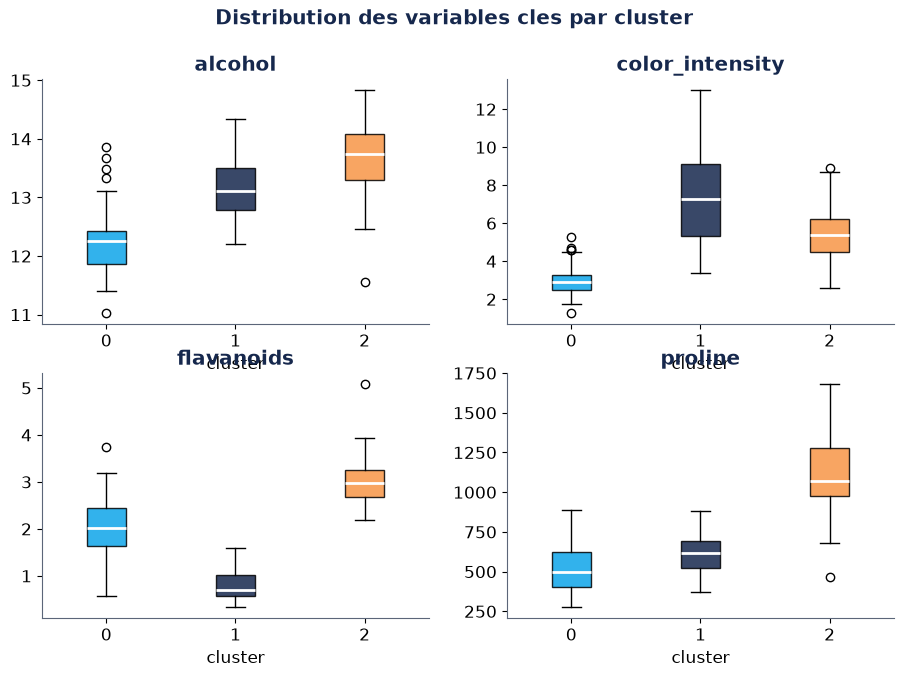

In [10]:
groupes = sorted(vins["cluster"].unique())
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), ["alcohol", "color_intensity", "flavanoids", "proline"]):
    paquets = [vins.loc[vins["cluster"] == c, col] for c in groupes]
    bp = ax.boxplot(paquets, patch_artist=True, medianprops=dict(color="white", lw=2))
    for patch, c in zip(bp["boxes"], groupes):
        patch.set(facecolor=PALETTE[c], alpha=0.85)
    ax.set_title(col); ax.set_xlabel("cluster")
    ax.set_xticks(range(1, len(groupes) + 1)); ax.set_xticklabels(groupes)
fig.suptitle("Distribution des variables cles par cluster", color=NAVY, fontweight="bold")
plt.show()

> **Lecture.** `proline` et `flavanoids` separent tres nettement les clusters
> (boites quasi disjointes) : ce sont les variables **les plus discriminantes**.
> `color_intensity` isole surtout un cluster (les vins les plus colores), tandis que
> `alcohol` se recouvre davantage : **seul**, il ne suffirait pas a distinguer les vins.

### 6.b Signature complete : heatmap des moyennes standardisees

Pour comparer les 13 variables d'un seul coup d'oeil, on calcule la **moyenne
standardisee** de chaque variable dans chaque cluster. Case **rouge** = cluster
nettement **au-dessus** de la moyenne generale ; **bleue** = en dessous.

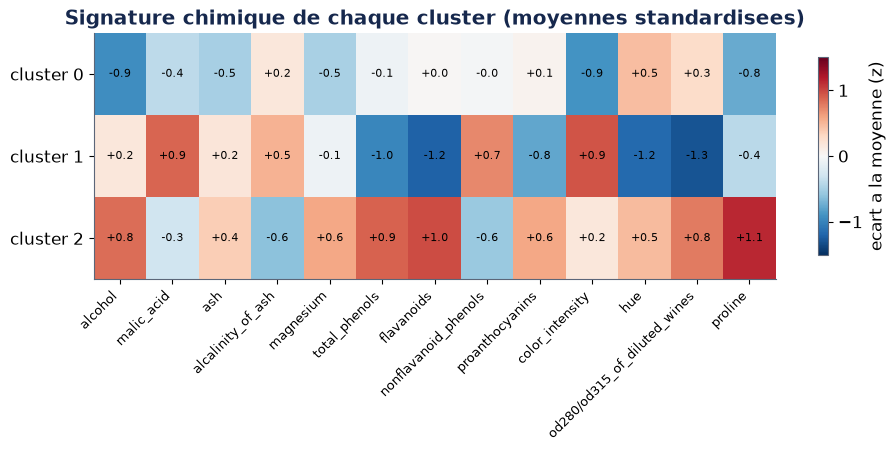

In [11]:
profil_z = pd.DataFrame(X_std, columns=X.columns)
profil_z["cluster"] = labels
moyennes_z = profil_z.groupby("cluster").mean()

fig, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(moyennes_z, cmap="RdBu_r", vmin=-1.5, vmax=1.5, aspect="auto")
ax.set_xticks(range(len(X.columns))); ax.set_xticklabels(X.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(moyennes_z))); ax.set_yticklabels([f"cluster {c}" for c in moyennes_z.index])
for i in range(moyennes_z.shape[0]):
    for j in range(moyennes_z.shape[1]):
        ax.text(j, i, f"{moyennes_z.iloc[i, j]:+.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="ecart a la moyenne (z)")
ax.set_title("Signature chimique de chaque cluster (moyennes standardisees)")
plt.show()

> **Interpretation des profils.** Chaque cluster a une identite chimique claire :
> - un cluster **riche en proline, alcool et phenols** (flavanoids/total_phenols
>   eleves) : des vins **corpulents** ;
> - un cluster **pauvre en flavonoides et phenols**, a forte `malic_acid` : des vins
>   plus **acides et legers** en arome ;
> - un cluster a **forte intensite de couleur** : des vins tres **colores**.
>
> Rapproches du tableau croise de l'etape 3, ces profils correspondent bien aux
> **trois cepages** reels : la qualification donne enfin un *nom* aux clusters.

## 7. Aller plus loin : le clustering hierarchique (CAH)

K-means n'est pas la seule methode. La **Classification Ascendante Hierarchique
(CAH)** part de chaque vin isole, puis **fusionne** a chaque etape les deux
clusters les plus proches, jusqu'a n'en avoir qu'un seul. L'historique se lit sur
un **dendrogramme** que l'on "coupe" pour obtenir k clusters (ici, methode de
Ward, qui minimise la variance intra-cluster a chaque fusion).

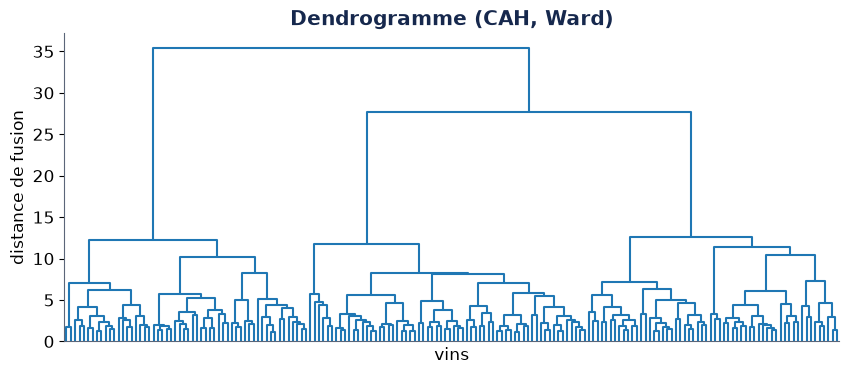

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Matrice de liaison (Ward) sur les donnees standardisees
Z = linkage(X_std, method="ward")

# 2. Dendrogramme
fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(Z, no_labels=True, color_threshold=0, ax=ax)
ax.set(title="Dendrogramme (CAH, Ward)", xlabel="vins", ylabel="distance de fusion")
plt.show()

In [13]:
from sklearn.cluster import AgglomerativeClustering

# 3. Couper l'arbre en 3 clusters
cah = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_cah = cah.fit_predict(X_std)

# 4. Comparer : CAH vs K-means, et CAH vs vrais cepages
print(f"ARI CAH vs K-means : {adjusted_rand_score(labels, labels_cah):.3f}")
print(f"ARI CAH vs cepages : {adjusted_rand_score(cepage, labels_cah):.3f}")
pd.crosstab(labels_cah, cepage, rownames=['CAH'], colnames=['cepage reel'])

ARI CAH vs K-means : 0.853
ARI CAH vs cepages : 0.790


cepage reel,0,1,2
CAH,,,
0,0,58,0
1,0,8,48
2,59,5,0


> CAH et K-means donnent ici des partitions tres proches (ARI eleve) : les trois
> cepages forment des groupes nets, retrouves par les deux methodes.

## A retenir

- **Standardiser** est indispensable avant K-means (et avant la CAH).
- On choisit `k` avec le **coude** + la **silhouette**.
- L'**ACP** permet de **visualiser** des clusters en haute dimension.
- La **CAH** est une alternative qui n'exige pas de fixer `k` (dendrogramme).
- Ici, on a pu **valider** les clusters contre les vrais cepages (ARI eleve).

## A vous de jouer
1. Relancez avec `k=2` puis `k=4` : la silhouette et l'ARI se degradent-ils ?
2. **Sans standardisation** (utilisez `X` au lieu de `X_std`), que devient l'ARI ?
3. Essayez d'autres `linkage` pour la CAH ("complete", "average") : l'ARI change-t-il ?